In [1]:
import jax.numpy as jnp
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# we want to use 64 bit floating precision
import jax
from jax import random

jax.config.update("jax_enable_x64", True)

# for plotting
sns.set_style("darkgrid")
# sns.set_theme(font_scale=1.25)

In [2]:
OUTPUT_DIR = (Path().resolve() / "..").resolve() / "report" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

A4_WIDTH_IN = 8.27

EXPORT_KWARGS = {
    "dpi": 600,
    "bbox_inches": "tight",
}

def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax, orientation="vertical")


def generate_samples(key, m, K, num_samples, jitter=0):
    """returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.


    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)

    returns
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))

    ##############################################
    # Your solution goes here
    ##############################################

    N = len(K)
    L = jnp.linalg.cholesky(K + jitter * jnp.identity(N))
    f_samples = m[:, None] + jnp.dot(L, zs)

    ##############################################
    # End of solution
    ##############################################

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), (
        f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    )
    return f_samples


# Task 1.4
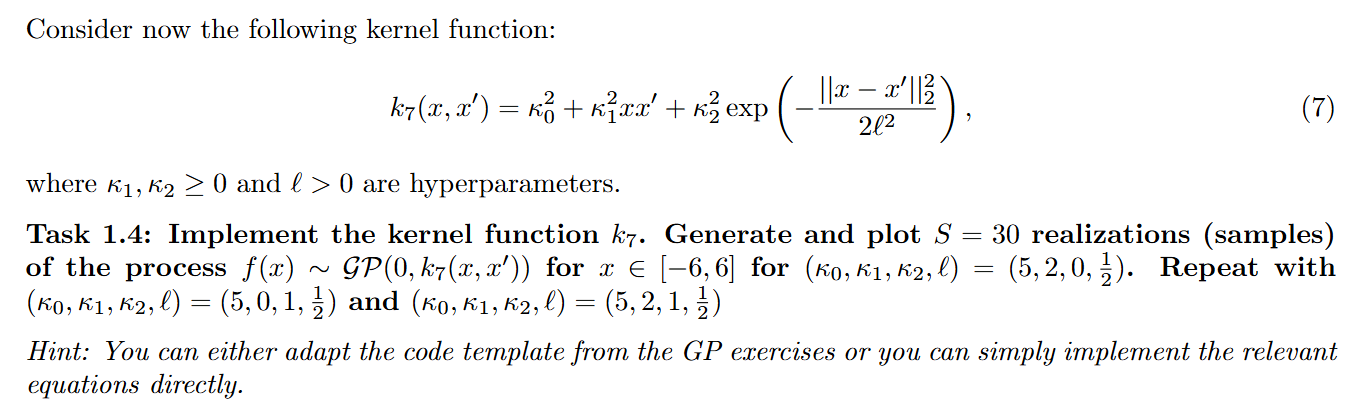

In [3]:
def k7(x, x_prime, kappa_0, kappa_1, kappa_2, ell):
    out = jnp.zeros_like(x)
    out += kappa_0**2
    out += (kappa_1**2) * (x * x_prime)

    norm = (x - x_prime) ** 2
    nom = norm
    denom = 2 * (ell**2)
    out += (kappa_2**2) * jnp.exp(-nom / denom)

    return out

key = random.PRNGKey(0)

S = 30
N_plot = 1000
mean = 0.0

x = jnp.linspace(-6, 6, N_plot)
x_prime = x
X, X_prime = jnp.meshgrid(x, x_prime)

kappa_0 = 5.0
kappa_1 = 0.0
kappa_2 = 1.0
ell = 0.5

K = k7(X, X_prime, kappa_0, kappa_1, kappa_2, ell)

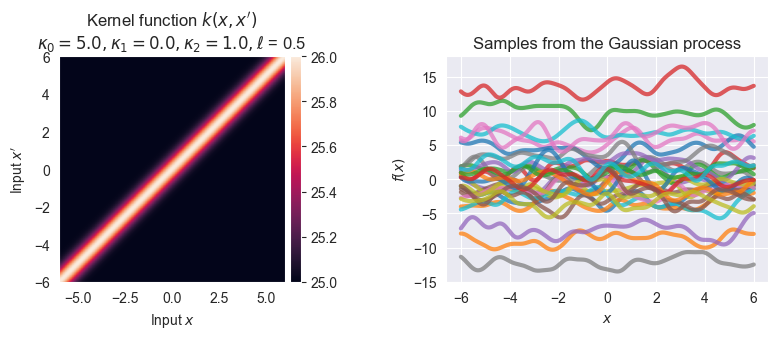

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(A4_WIDTH_IN, 3.5))

im = ax[0].pcolormesh(x.flatten(), x_prime.flatten(), K, shading="auto")
ax[0].set(
    xlabel="Input $x$",
    ylabel="Input $x'$",
    title=f"Kernel function $k(x, x')$\n$\\kappa_0 = {kappa_0:2.1f}, \\kappa_1 = {kappa_1:2.1f}, \\kappa_2 = {kappa_2:2.1f}, \\ell$ = {ell:2.1f}",
)
ax[0].grid(False)
ax[0].set_aspect("equal")
add_colorbar(im, fig, ax[0])

m = jnp.zeros(len(x))
f_samples = generate_samples(key, m, K, num_samples=S, jitter=1e-8)
ax[1].plot(x, f_samples, alpha=0.75, linewidth=3)
ax[1].grid(True)
ax[1].set(xlabel="$x$", ylabel="$f(x)$", title="Samples from the Gaussian process")

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "1_4-1.png", **EXPORT_KWARGS)


In [5]:
kappa_0 = 5.0
kappa_1 = 2.0
kappa_2 = 1.0
ell = 0.5

K = k7(X, X_prime, kappa_0, kappa_1, kappa_2, ell)

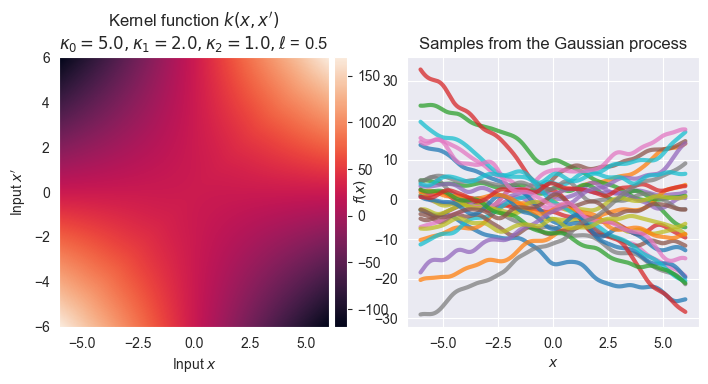

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(A4_WIDTH_IN, 3.5))

im = ax[0].pcolormesh(x.flatten(), x_prime.flatten(), K, shading="auto")
ax[0].set(
    xlabel="Input $x$",
    ylabel="Input $x'$",
    title=f"Kernel function $k(x, x')$\n$\\kappa_0 = {kappa_0:2.1f}, \\kappa_1 = {kappa_1:2.1f}, \\kappa_2 = {kappa_2:2.1f}, \\ell$ = {ell:2.1f}",
)
ax[0].grid(False)
ax[0].set_aspect("equal")
add_colorbar(im, fig, ax[0])

m = jnp.zeros(len(x))
f_samples = generate_samples(key, m, K, num_samples=S, jitter=1e-8)
ax[1].plot(x, f_samples, alpha=0.75, linewidth=3)
ax[1].grid(True)
ax[1].set(xlabel="$x$", ylabel="$f(x)$", title="Samples from the Gaussian process")
plt.savefig(OUTPUT_DIR / "1_4-2.png", **EXPORT_KWARGS)
